In [30]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
import joblib
from imblearn.over_sampling import SMOTENC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
import optuna
from sklearn.model_selection import KFold, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score
from optuna.visualization import plot_terminator_improvement
from optuna.terminator import report_cross_validation_scores
from sklearn.feature_selection import RFECV
from tabulate import tabulate
import json
import matplotlib.pyplot as plt

In [2]:
bank= pd.read_csv("/kaggle/input/datasets/prahazra/final-bank-data/Final_bank_data.csv")

In [3]:
X_train, x_test,Y_train, y_test= train_test_split(bank.drop('Exited', axis=1), bank['Exited'], test_size=0.2, random_state=42)

In [4]:
columns= X_train.columns
categorical_cols= []
numerical_cols= []
for col in columns:
  if bank[col].dtype == 'object' or bank[col].dtype == 'category':
    categorical_cols.append(col)
  else:
    numerical_cols.append(col)

In [5]:
smote_nc = SMOTENC(categorical_features=categorical_cols, random_state=42)
X_train_resampled, Y_train_resampled = smote_nc.fit_resample(X_train, Y_train)

In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols),
        ('scaler', StandardScaler(), numerical_cols)
    ],
    remainder='passthrough'
)

In [7]:
X_train_preprocessed = preprocessor.fit_transform(X_train_resampled)
x_test_preprocessed = preprocessor.transform(x_test)

In [8]:
joblib.dump(preprocessor, 'preprocessor.joblib')

['preprocessor.joblib']

In [9]:
LR= LogisticRegression(random_state= 42)
DT= DecisionTreeClassifier(random_state= 42)
RF= RandomForestClassifier(random_state = 42)
GB= GradientBoostingClassifier(random_state= 42)
XGB= XGBClassifier(random_state= 42)

In [10]:
LR.fit(X_train_preprocessed, Y_train_resampled)
DT.fit(X_train_preprocessed, Y_train_resampled)
RF.fit(X_train_preprocessed, Y_train_resampled)
GB.fit(X_train_preprocessed, Y_train_resampled)
XGB.fit(X_train_preprocessed, Y_train_resampled)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [11]:
Models= {
    "Logistic Regression": LR,
    "Decision Tree": DT,
    "Random Forest": RF,
    "Gradient Boosting": GB,
    "XGBoost": XGB
}


performance= []
for name, model in Models.items():
    y_pred= model.predict(x_test_preprocessed)
    accuracy= accuracy_score(y_test, y_pred)
    performance.append([name, f"{accuracy * 100:.2f}%"])

headers= ['Model', 'Test Accuracy']
print(tabulate(performance, headers= headers, tablefmt= 'grid'))

+---------------------+-----------------+
| Model               | Test Accuracy   |
+=====================+=================+
| Logistic Regression | 77.90%          |
+---------------------+-----------------+
| Decision Tree       | 78.25%          |
+---------------------+-----------------+
| Random Forest       | 85.30%          |
+---------------------+-----------------+
| Gradient Boosting   | 85.05%          |
+---------------------+-----------------+
| XGBoost             | 85.80%          |
+---------------------+-----------------+


Since, Decision tree is significantly producing less accuracy so we will discard it from our study and we will continue with Random Forest, Gradient Boosting, and XGBoost along with the baseline Logistic Regression.

In [12]:
sampler= optuna.samplers.TPESampler(seed =42)

In [13]:
def objective_LR(trial):
    all_possible_solvers = ['liblinear', 'saga', 'newton-cg', 'lbfgs', 'sag', 'newton-cholesky']
    solver = trial.suggest_categorical('solver', all_possible_solvers)

    if solver == 'liblinear':
        penalty = trial.suggest_categorical('penalty_liblinear', ['l1', 'l2'])
    elif solver in ['newton-cg', 'lbfgs', 'sag', 'newton-cholesky']:
        penalty = trial.suggest_categorical('penalty_standard', ['l2', None])
    elif solver == 'saga':
        penalty = trial.suggest_categorical('penalty_saga', ['l1', 'l2', 'elasticnet', None])

    C = trial.suggest_float('C', 1e-5, 10.0, log=True)
    tolerance = trial.suggest_float('tol', 1e-5, 1e-3, log=True)
    max_iter = trial.suggest_int('max_iter', 100, 1000)

    params = {
        'penalty': penalty,
        'C': C,
        'tol': tolerance,
        'solver': solver,
        'max_iter': max_iter,
        'random_state': 42
    }

    if penalty == 'elasticnet':
        params['l1_ratio'] = trial.suggest_float('l1_ratio', 0.0, 1.0)

    try:
        model = LogisticRegression(**params)
        scores = cross_val_score(model, X_train_preprocessed, Y_train_resampled, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state= 42))
        report_cross_validation_scores(trial, scores)

        return np.mean(scores)

    except Exception as e:
        raise optuna.TrialPruned(f"Pruned due to runtime error: {e}")

In [14]:
study_LR = optuna.create_study(direction="maximize", study_name= "Optimize_LR", sampler= sampler)
study_LR.optimize(objective_LR, n_trials=50, show_progress_bar=True)

[I 2026-05-27 00:55:26,723] A new study created in memory with name: Optimize_LR


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-27 00:55:27,224] Trial 0 finished with value: 0.7198704702407344 and parameters: {'solver': 'saga', 'penalty_saga': 'l2', 'C': 1.3289448722869181e-05, 'tol': 0.0008706020878304854, 'max_iter': 850}. Best is trial 0 with value: 0.7198704702407344.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means 

[I 2026-05-27 00:55:43,414] Trial 1 finished with value: 0.8161577747093036 and parameters: {'solver': 'sag', 'penalty_standard': None, 'C': 6.870101665590028e-05, 'tol': 3.8396292998041685e-05, 'max_iter': 430}. Best is trial 1 with value: 0.8161577747093036.


...

[I 2026-05-27 00:59:11,826] Trial 47 finished with value: 0.8167872003583987 and parameters: {'solver': 'newton-cholesky', 'penalty_standard': None, 'C': 4.498887721087767, 'tol': 0.00030153812730728875, 'max_iter': 588}. Best is trial 45 with value: 0.8170232349768096.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_glm/_newton_solver.py:576: LinAlgWarning: The inner solver of NewtonCholeskySolver stumbled upon a singular or very ill-conditioned Hessian matrix at iteration 1. It will now resort to lbfgs instead.
Further options are to use another solver or to avoid such situation in the first place. Possible remedies are removing collinear features of X or increasing the penalization strengths.
The original Linear Algebra message was:
Matrix is singular.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_glm/_newton_solver.py:576: LinAlgWarning: The inner solver of NewtonCholeskySolver stumbled upon a singular or very ill-conditioned Hessian matrix at iteration 1. It will now resort to lbfgs instead.
Further options are to use another solv

[I 2026-05-27 00:59:12,805] Trial 48 finished with value: 0.8170232349768096 and parameters: {'solver': 'newton-cholesky', 'penalty_standard': None, 'C': 0.7484958896350706, 'tol': 0.0003226280588575224, 'max_iter': 578}. Best is trial 45 with value: 0.8170232349768096.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_glm/_newton_solver.py:576: LinAlgWarning: The inner solver of NewtonCholeskySolver stumbled upon a singular or very ill-conditioned Hessian matrix at iteration 1. It will now resort to lbfgs instead.
Further options are to use another solver or to avoid such situation in the first place. Possible remedies are removing collinear features of X or increasing the penalization strengths.
The original Linear Algebra message was:
Matrix is singular.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_glm/_newton_solver.py:576: LinAlgWarning: The inner solver of NewtonCholeskySolver stumbled upon a singular or very ill-conditioned Hessian matrix at iteration 1. It will now resort to lbfgs instead.
Further options are to use another solv

[I 2026-05-27 00:59:13,715] Trial 49 finished with value: 0.8167872003583987 and parameters: {'solver': 'newton-cholesky', 'penalty_standard': None, 'C': 5.663137499827341, 'tol': 0.0002979598730293553, 'max_iter': 588}. Best is trial 45 with value: 0.8170232349768096.


In [16]:
fig= plot_terminator_improvement(study_LR, plot_error = True)
fig.show()

/tmp/ipykernel_57/3908929248.py:1: ExperimentalWarning:

optuna.visualization._terminator_improvement.plot_terminator_improvement is experimental (supported from v3.2.0). The interface can change in the future.

/usr/local/lib/python3.12/dist-packages/optuna/visualization/_terminator_improvement.py:93: ExperimentalWarning:

RegretBoundEvaluator is experimental (supported from v3.2.0). The interface can change in the future.

/usr/local/lib/python3.12/dist-packages/optuna/visualization/_terminator_improvement.py:98: ExperimentalWarning:

CrossValidationErrorEvaluator is experimental (supported from v3.2.0). The interface can change in the future.

100%|██████████| 50/50 [00:04<00:00, 12.04it/s]


In [17]:
def objective_RF(trial):
  params = {
      'n_estimators': trial.suggest_int('n_estimators', 50, 500), # Corrected parameter name
      'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy', 'log_loss']), # Corrected parameter name
      'min_impurity_decrease': trial.suggest_float('min_impurity_decrease', 0.0, 0.5), # Corrected parameter name
      'bootstrap': trial.suggest_categorical('bootstrap', [True, False]), # Corrected parameter name
      'class_weight': trial.suggest_categorical('class_weight', ['balanced', 'balanced_subsample', None]), # Corrected parameter name
      'ccp_alpha': trial.suggest_float('ccp_alpha', 0.0, 0.1), # Corrected parameter name
      'random_state': 42
  }

  max_features_option = trial.suggest_categorical('max_features_option', ['sqrt', 'log2', None, 'float']) # Corrected parameter name
  if max_features_option == 'float':
      params['max_features'] = trial.suggest_float('max_features_rf_float', 0.1, 1.0)
  else:
      params['max_features'] = max_features_option # Assign directly to 'max_features'



  try:
      model = RandomForestClassifier(**params)
      scores = cross_val_score(model, X_train_preprocessed, Y_train_resampled, cv=StratifiedKFold(n_splits=5, shuffle=True,random_state= 42))
      report_cross_validation_scores(trial, scores)

      return np.mean(scores)

  except Exception as e:
      raise optuna.TrialPruned(f"Pruned due to runtime error: {e}")

In [18]:
study_RF = optuna.create_study(direction="maximize", study_name= "Optimize_RF", sampler= sampler)
study_RF.optimize(objective_RF, n_trials=50, show_progress_bar=True)

[I 2026-05-27 00:59:50,391] A new study created in memory with name: Optimize_RF


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-27 01:00:04,141] Trial 0 finished with value: 0.7416617035146542 and parameters: {'n_estimators': 293, 'criterion': 'entropy', 'min_impurity_decrease': 0.05502596226383838, 'bootstrap': False, 'class_weight': 'balanced_subsample', 'ccp_alpha': 0.05107473025775658, 'max_features_option': 'sqrt'}. Best is trial 0 with value: 0.7416617035146542.
[I 2026-05-27 01:00:19,433] Trial 1 finished with value: 0.5000786472670076 and parameters: {'n_estimators': 475, 'criterion': 'log_loss', 'min_impurity_decrease': 0.181814801189647, 'bootstrap': True, 'class_weight': 'balanced_subsample', 'ccp_alpha': 0.028484049437746763, 'max_features_option': 'log2'}. Best is trial 0 with value: 0.7416617035146542.
[I 2026-05-27 01:00:35,777] Trial 2 finished with value: 0.4999213527329925 and parameters: {'n_estimators': 175, 'criterion': 'gini', 'min_impurity_decrease': 0.2447263801387815, 'bootstrap': True, 'class_weight': 'balanced_subsample', 'ccp_alpha': 0.07282163486118597, 'max_features_opti

In [19]:
fig= plot_terminator_improvement(study_RF, plot_error = True)
fig.show()

/tmp/ipykernel_57/2361534508.py:1: ExperimentalWarning:

optuna.visualization._terminator_improvement.plot_terminator_improvement is experimental (supported from v3.2.0). The interface can change in the future.

/usr/local/lib/python3.12/dist-packages/optuna/visualization/_terminator_improvement.py:93: ExperimentalWarning:

RegretBoundEvaluator is experimental (supported from v3.2.0). The interface can change in the future.

/usr/local/lib/python3.12/dist-packages/optuna/visualization/_terminator_improvement.py:98: ExperimentalWarning:

CrossValidationErrorEvaluator is experimental (supported from v3.2.0). The interface can change in the future.

100%|██████████| 50/50 [00:05<00:00,  9.16it/s]


In [20]:
def objective_GB(trial):
  params = {
      'loss': trial.suggest_categorical('loss', ['log_loss', 'exponential']), # Corrected parameter name
      'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True), # Corrected parameter name
      'n_estimators': trial.suggest_int('n_estimators', 50, 500), # Corrected parameter name
      'criterion': trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error']), # Corrected parameter name
      'min_samples_split': trial.suggest_int('min_samples_split', 2, 20), # Corrected parameter name
      'min_impurity_decrease': trial.suggest_float('min_impurity_decrease', 0.0, 0.5), # Corrected parameter name
      'max_depth': trial.suggest_int('max_depth', 1, 20), # Corrected parameter name
      'random_state': 42
  }

  max_features_option = trial.suggest_categorical('max_features_option', ['sqrt', 'log2', None, 'float']) # Corrected parameter name
  if max_features_option == 'float':
      params['max_features'] = trial.suggest_float('max_features_gb_float', 0.1, 1.0)
  else:
      params['max_features'] = max_features_option # Assign directly to 'max_features'



  try:
      model = GradientBoostingClassifier(**params)
      scores = cross_val_score(model, X_train_preprocessed, Y_train_resampled, cv=StratifiedKFold(n_splits=5, shuffle=True,random_state= 42))
      report_cross_validation_scores(trial, scores)

      return np.mean(scores)

  except Exception as e:
      raise optuna.TrialPruned(f"Pruned due to runtime error: {e}")

In [21]:
study_GB = optuna.create_study(direction="maximize", study_name= "Optimize_GB", sampler = sampler)
study_GB.optimize(objective_GB, n_trials=50, show_progress_bar=True)

[I 2026-05-27 01:22:53,882] A new study created in memory with name: Optimize_GB


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-27 01:23:10,902] Trial 0 finished with value: 0.8919919323126102 and parameters: {'loss': 'exponential', 'learning_rate': 0.19088462590130242, 'n_estimators': 461, 'criterion': 'friedman_mse', 'min_samples_split': 17, 'min_impurity_decrease': 0.3249819653888826, 'max_depth': 15, 'max_features_option': 'log2'}. Best is trial 0 with value: 0.8919919323126102.
[I 2026-05-27 01:23:17,815] Trial 1 finished with value: 0.7728131063102521 and parameters: {'loss': 'exponential', 'learning_rate': 0.011300329228083602, 'n_estimators': 259, 'criterion': 'friedman_mse', 'min_samples_split': 13, 'min_impurity_decrease': 0.015250124969524714, 'max_depth': 1, 'max_features_option': 'sqrt'}. Best is trial 0 with value: 0.8919919323126102.
[I 2026-05-27 01:23:20,021] Trial 2 finished with value: 0.4999213527329925 and parameters: {'loss': 'log_loss', 'learning_rate': 0.08319261221667239, 'n_estimators': 88, 'criterion': 'squared_error', 'min_samples_split': 12, 'min_impurity_decrease': 0.318

In [22]:
fig= plot_terminator_improvement(study_GB, plot_error = True)
fig.show()

/tmp/ipykernel_57/2307288078.py:1: ExperimentalWarning:

optuna.visualization._terminator_improvement.plot_terminator_improvement is experimental (supported from v3.2.0). The interface can change in the future.

/usr/local/lib/python3.12/dist-packages/optuna/visualization/_terminator_improvement.py:93: ExperimentalWarning:

RegretBoundEvaluator is experimental (supported from v3.2.0). The interface can change in the future.

/usr/local/lib/python3.12/dist-packages/optuna/visualization/_terminator_improvement.py:98: ExperimentalWarning:

CrossValidationErrorEvaluator is experimental (supported from v3.2.0). The interface can change in the future.

100%|██████████| 50/50 [00:06<00:00,  7.36it/s]


In [23]:
def objective_XGB(trial):
  params = {
      'n_estimators': trial.suggest_int('n_estimators', 50, 500), # Corrected parameter name
      'max_depth': trial.suggest_int('max_depth', 1, 20), # Corrected parameter name
      'grow_policy': trial.suggest_categorical('grow_policy', ['depthwise', 'lossguide']), # Corrected parameter name
      'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True), # Corrected parameter name
      'booster': trial.suggest_categorical('booster', ['gbtree', 'gblinear', 'dart']), # Corrected parameter name
      'gamma': trial.suggest_float('gamma', 0.0, 0.5), # Corrected parameter name
      'min_child_weight': trial.suggest_int('min_child_weight', 1, 10), # Corrected parameter name
      'use_label_encoder': False, # Suppress warning
      'eval_metric': 'logloss', # Suppress warning
      'random_state': 42
  }



  try:
      model = XGBClassifier(**params)
      scores = cross_val_score(model, X_train_preprocessed, Y_train_resampled, cv=StratifiedKFold(n_splits=5, shuffle=True,random_state= 42))
      report_cross_validation_scores(trial, scores)

      return np.mean(scores)

  except Exception as e:
      raise optuna.TrialPruned(f"Pruned due to runtime error: {e}")

In [24]:
study_XGB = optuna.create_study(direction="maximize", study_name= "Optimize_XGB", sampler= sampler)
study_XGB.optimize(objective_XGB, n_trials=50, show_progress_bar=True)

[I 2026-05-27 02:07:39,132] A new study created in memory with name: Optimize_XGB


  0%|          | 0/50 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[02:07:39] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[02:09:15] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[02:10:53] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[02:12:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[02:14:07] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.




[I 2026-05-27 02:15:42,305] Trial 0 finished with value: 0.8987576083186657 and parameters: {'n_estimators': 457, 'max_depth': 11, 'grow_policy': 'depthwise', 'learning_rate': 0.21027923816150645, 'booster': 'dart', 'gamma': 0.04564333839306678, 'min_child_weight': 4}. Best is trial 0 with value: 0.8987576083186657.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[02:15:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[02:17:33] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[02:19:24] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[02:21:17] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[02:23:08] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.




...

[I 2026-05-27 02:53:25,647] Trial 47 finished with value: 0.8095496716894279 and parameters: {'n_estimators': 173, 'max_depth': 5, 'grow_policy': 'lossguide', 'learning_rate': 0.08669862012035673, 'booster': 'gblinear', 'gamma': 0.26927807465392806, 'min_child_weight': 10}. Best is trial 18 with value: 0.9056797435022415.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[02:53:25] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[02:53:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[02:53:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[02:53:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[02:53:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.




[I 2026-05-27 02:53:28,804] Trial 48 finished with value: 0.9011171500854076 and parameters: {'n_estimators': 342, 'max_depth': 9, 'grow_policy': 'depthwise', 'learning_rate': 0.1523083506539842, 'booster': 'gbtree', 'gamma': 0.25327614472116117, 'min_child_weight': 7}. Best is trial 18 with value: 0.9056797435022415.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[02:53:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[02:53:29] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[02:53:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[02:53:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[02:53:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.




[I 2026-05-27 02:53:33,570] Trial 49 finished with value: 0.9021397811304105 and parameters: {'n_estimators': 276, 'max_depth': 6, 'grow_policy': 'lossguide', 'learning_rate': 0.055681789357422795, 'booster': 'gbtree', 'gamma': 0.17384004141429535, 'min_child_weight': 9}. Best is trial 18 with value: 0.9056797435022415.


In [25]:
fig= plot_terminator_improvement(study_XGB, plot_error = True)
fig.show()

/tmp/ipykernel_57/776746673.py:1: ExperimentalWarning:

optuna.visualization._terminator_improvement.plot_terminator_improvement is experimental (supported from v3.2.0). The interface can change in the future.

/usr/local/lib/python3.12/dist-packages/optuna/visualization/_terminator_improvement.py:93: ExperimentalWarning:

RegretBoundEvaluator is experimental (supported from v3.2.0). The interface can change in the future.

/usr/local/lib/python3.12/dist-packages/optuna/visualization/_terminator_improvement.py:98: ExperimentalWarning:

CrossValidationErrorEvaluator is experimental (supported from v3.2.0). The interface can change in the future.

100%|██████████| 50/50 [00:05<00:00,  9.30it/s]


In [26]:
Model_names= ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'XGBoost']
Model_scores= [study_LR.best_trial.value, study_RF.best_trial.value, study_GB.best_trial.value, study_XGB.best_trial.value]
Model_params= [study_LR.best_trial.params, study_RF.best_trial.params, study_GB.best_trial.params, study_XGB.best_trial.params]
performance= pd.DataFrame({'Model': Model_names, 'Score': Model_scores, 'Parameters': Model_params})
performance[['Model', 'Score']]

,Model,Score
0,Logistic Regression,0.817023
1,Random Forest,0.863121
2,Gradient Boosting,0.905837
3,XGBoost,0.905680


From, these scores it is evident that we should choose Gradient Boosting and XGBoost for further analysis, since they significantly out performs Random Forest.

In [27]:
def save_params(prefix_name, params_dict):
    file_name= f"{prefix_name}.json"
    with open(file_name, "w") as f:
        json.dump(params_dict, f, indent= 4)
    print(f"Successfully saved to: {file_name}")

In [28]:
LR_params1= study_LR.best_params
save_params("LR_params1", LR_params1)
GB_params1= study_GB.best_params
save_params("GB_params1", GB_params1)
XGB_params1= study_XGB.best_params
save_params("XGB_params1", XGB_params1)

Successfully saved to: LR_params1.json
Successfully saved to: GB_params1.json
Successfully saved to: XGB_params1.json


# Recursive Feature Elimination

Now, that we have seen the model performance with all features, lets see if removing some of them degrades the model performance or not.

Optimal number of features: 23
Selected Features: ['onehot__Geography_Germany', 'onehot__Gender_Male', 'onehot__AgeGroup_Old', 'onehot__AgeGroup_Young', 'onehot__TenureRiskGroup_Mid_Stable', 'scaler__CreditScore', 'scaler__Age', 'scaler__Tenure', 'scaler__Balance', 'scaler__NumOfProducts', 'scaler__HasCrCard', 'scaler__IsActiveMember', 'scaler__BalanceSalaryRatio', 'scaler__TenureAgeRatio', 'scaler__CreditScoreAgeRatio', 'scaler__AgeBalanceInteraction', 'scaler__ProductDensity', 'scaler__LoyalityScore', 'scaler__GermanPassiveWealth', 'scaler__BalancePerProduct', 'scaler__CardButInactive', 'scaler__CardAndActive', 'scaler__Female_Germany']


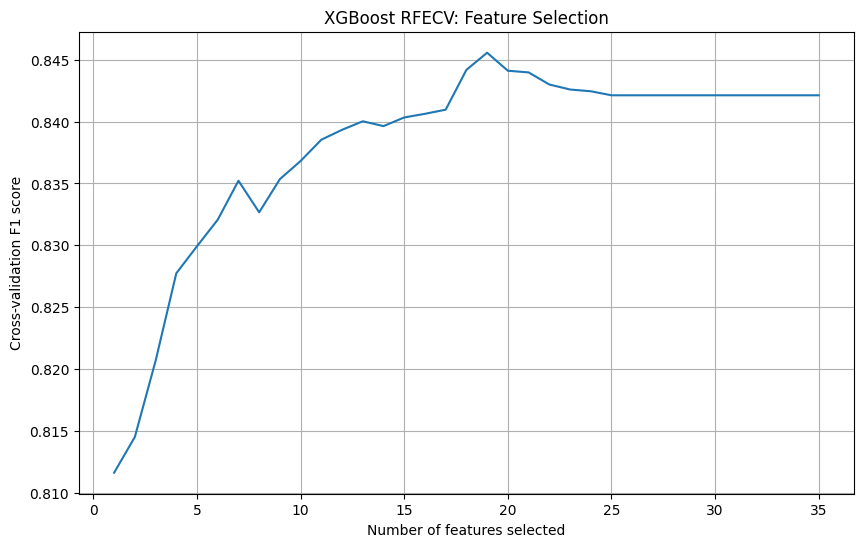

In [31]:
estimator = GradientBoostingClassifier(
    n_estimators=50,       # Keep tree count low for speed during selection
    max_depth=3,           # Shallow trees prevent overfitting during this phase
    learning_rate=0.1,
    random_state=42        # Ensures reproducible feature selection
)

# 2. Initialize RFECV
cv = StratifiedKFold(n_splits=5)
selector = RFECV(
    estimator=estimator,
    step=1,               # Remove 1 feature at a time
    cv=cv,
    scoring='f1',         # Metric suited for imbalanced data like churn
    min_features_to_select=5,
    n_jobs=-1
)

# 3. Fit the selector
selector = selector.fit(X_train_preprocessed, Y_train_resampled)

# 4. Extract optimal features
optimal_num_features = selector.n_features_

# Get feature names after preprocessing
preprocessed_feature_names = preprocessor.get_feature_names_out()

# Use the boolean mask from RFECV to select the corresponding feature names
selected_features = preprocessed_feature_names[selector.support_]

print(f"Optimal number of features: {optimal_num_features}")
print(f"Selected Features: {list(selected_features)}")

# 5. Filter your datasets to include only the selected features
X_train_rfe = selector.transform(X_train_preprocessed)
X_test_rfe = selector.transform(x_test_preprocessed)

# Optional: Plot the results to see the performance curve
plt.figure(figsize=(10, 6))
plt.title("XGBoost RFECV: Feature Selection")
plt.xlabel("Number of features selected")
plt.ylabel("Cross-validation F1 score")
plt.plot(range(1, len(selector.cv_results_['mean_test_score']) + 1), selector.cv_results_['mean_test_score'])
plt.grid(True)
plt.show()

In [32]:
model1 = LogisticRegression(random_state=42, max_iter=1000)
model2 = RandomForestClassifier(random_state=42, n_estimators=100)
model3 = GradientBoostingClassifier(random_state=42, n_estimators=100) # Full model

# 2. Train (Fit) the fresh models on the RFE-selected training data
model1.fit(X_train_rfe, Y_train_resampled)
model2.fit(X_train_rfe, Y_train_resampled)
model3.fit(X_train_rfe, Y_train_resampled)

# 3. Store the newly trained models in a dictionary
New_Models = {
    "Logistic Regression (RFE)": model1,
    "Random Forest (RFE)": model2,
    "Gradient Boosting (RFE)": model3
}

# 4. Loop through and evaluate using the RFE-selected test data
performance = []
for name, model in New_Models.items():
    # Use X_test_rfe to match the expected feature count
    y_pred = model.predict(X_test_rfe)
    
    accuracy = accuracy_score(y_test, y_pred)
    performance.append([name, f"{accuracy * 100:.2f}%"])

# 5. Print your clean results table
print(tabulate(performance, headers=["Model Name", "Test Accuracy"], tablefmt="grid"))

+---------------------------+-----------------+
| Model Name                | Test Accuracy   |
+===========================+=================+
| Logistic Regression (RFE) | 78.15%          |
+---------------------------+-----------------+
| Random Forest (RFE)       | 85.75%          |
+---------------------------+-----------------+
| Gradient Boosting (RFE)   | 85.45%          |
+---------------------------+-----------------+


In [33]:
def objective_LR2(trial):
    # 1. Nest the penalty choice based on compatible solvers
    all_possible_solvers = ['liblinear', 'saga', 'newton-cg', 'lbfgs', 'sag', 'newton-cholesky']
    solver = trial.suggest_categorical('solver', all_possible_solvers)

    if solver == 'liblinear':
        penalty = trial.suggest_categorical('penalty_liblinear', ['l1', 'l2'])
    elif solver in ['newton-cg', 'lbfgs', 'sag', 'newton-cholesky']:
        penalty = trial.suggest_categorical('penalty_standard', ['l2', None])
    elif solver == 'saga':
        penalty = trial.suggest_categorical('penalty_saga', ['l1', 'l2', 'elasticnet', None])

    # 2. Extract standard hyperparameters
    C = trial.suggest_float('C', 1e-5, 10.0, log=True)
    tolerance = trial.suggest_float('tol', 1e-5, 1e-3, log=True)
    max_iter = trial.suggest_int('max_iter', 100, 1000)

    params = {
        'penalty': penalty,
        'C': C,
        'tol': tolerance,
        'solver': solver,
        'max_iter': max_iter,
        'random_state': 42
    }

    if penalty == 'elasticnet':
        params['l1_ratio'] = trial.suggest_float('l1_ratio', 0.0, 1.0)

    # 3. Use Try-Except block to handle unexpected Sklearn runtime mismatches
    try:
        model = LogisticRegression(**params)
        scores = cross_val_score(model, X_train_rfe, Y_train_resampled, cv=StratifiedKFold(n_splits=5, shuffle=True,random_state= 42))

        # This function sets the _CROSS_VALIDATION_SCORES_KEY needed by the terminator plot
        report_cross_validation_scores(trial, scores)

        return np.mean(scores)

    except Exception as e:
        # If a configuration still errors out, prune the trial safely
        raise optuna.TrialPruned(f"Pruned due to runtime error: {e}")


sampler= optuna.samplers.TPESampler(seed =42)
study_LR2 = optuna.create_study(direction="maximize", study_name= "Optimize_LR2", sampler= sampler)
study_LR2.optimize(objective_LR2, n_trials=50, show_progress_bar=True)

[I 2026-05-27 03:04:35,060] A new study created in memory with name: Optimize_LR2


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-27 03:04:35,395] Trial 0 finished with value: 0.7337944707444233 and parameters: {'solver': 'saga', 'penalty_saga': 'l2', 'C': 1.3289448722869181e-05, 'tol': 0.0008706020878304854, 'max_iter': 850}. Best is trial 0 with value: 0.7337944707444233.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning:

Setting penalty=None will ignore the C and l1_ratio parameters

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning:

Setting penalty=None will ignore the C and l1_ratio parameters

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning:

Setting penalty=None will ignore the C and l1_ratio parameters

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning:

The max_iter was reached which means the coef_ did not converge

/usr/local/lib/python3.12/dist-packages/sklear

[I 2026-05-27 03:04:45,508] Trial 1 finished with value: 0.8098649723574347 and parameters: {'solver': 'sag', 'penalty_standard': None, 'C': 6.870101665590028e-05, 'tol': 3.8396292998041685e-05, 'max_iter': 430}. Best is trial 1 with value: 0.8098649723574347.


...

[I 2026-05-27 03:06:02,045] Trial 28 finished with value: 0.8094717050832682 and parameters: {'solver': 'lbfgs', 'penalty_standard': None, 'C': 0.16709781384901295, 'tol': 0.00030525058233131844, 'max_iter': 330}. Best is trial 21 with value: 0.8115951194142109.
[I 2026-05-27 03:06:02,466] Trial 29 finished with value: 0.8098650342356937 and parameters: {'solver': 'liblinear', 'penalty_liblinear': 'l2', 'C': 1.7332235092784223, 'tol': 0.000667985207104979, 'max_iter': 521}. Best is trial 21 with value: 0.8115951194142109.
[I 2026-05-27 03:06:03,458] Trial 30 finished with value: 0.810100976036716 and parameters: {'solver': 'liblinear', 'penalty_liblinear': 'l1', 'C': 0.26167276769508213, 'tol': 0.0009357021421050287, 'max_iter': 442}. Best is trial 21 with value: 0.8115951194142109.
[I 2026-05-27 03:06:04,334] Trial 31 finished with value: 0.8114376701845488 and parameters: {'solver': 'liblinear', 'penalty_liblinear': 'l1', 'C': 0.0912156200014121, 'tol': 0.00029637363559511333, 'max_i

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning:

Setting penalty=None will ignore the C and l1_ratio parameters

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning:

Setting penalty=None will ignore the C and l1_ratio parameters

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning:

Setting penalty=None will ignore the C and l1_ratio parameters

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning:

Setting penalty=None will ignore the C and l1_ratio parameters

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning:

Setting penalty=None will ignore the C and l1_ratio parameters



[I 2026-05-27 03:06:18,430] Trial 36 finished with value: 0.8100222978305792 and parameters: {'solver': 'saga', 'penalty_saga': 'elasticnet', 'C': 0.465222745226828, 'tol': 0.00037658653464781825, 'max_iter': 458, 'l1_ratio': 0.026815191458480936}. Best is trial 21 with value: 0.8115951194142109.
[I 2026-05-27 03:06:18,569] Trial 37 finished with value: 0.810100976036716 and parameters: {'solver': 'newton-cholesky', 'penalty_standard': None, 'C': 0.11892329469798484, 'tol': 0.000528174061310207, 'max_iter': 847}. Best is trial 21 with value: 0.8115951194142109.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning:

Setting penalty=None will ignore the C and l1_ratio parameters

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning:

Setting penalty=None will ignore the C and l1_ratio parameters

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning:

Setting penalty=None will ignore the C and l1_ratio parameters

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning:

Setting penalty=None will ignore the C and l1_ratio parameters

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1207: UserWarning:

Setting penalty=None will ignore the C and l1_ratio parameters



[I 2026-05-27 03:06:19,047] Trial 38 finished with value: 0.8095502595328872 and parameters: {'solver': 'lbfgs', 'penalty_standard': None, 'C': 0.00870841291848976, 'tol': 0.00013409303163142695, 'max_iter': 579}. Best is trial 21 with value: 0.8115951194142109.
[I 2026-05-27 03:06:19,487] Trial 39 finished with value: 0.8065603330040378 and parameters: {'solver': 'liblinear', 'penalty_liblinear': 'l1', 'C': 0.030487560708536927, 'tol': 0.0006992685371708364, 'max_iter': 711}. Best is trial 21 with value: 0.8115951194142109.
[I 2026-05-27 03:06:30,760] Trial 40 finished with value: 0.8100223287697086 and parameters: {'solver': 'saga', 'penalty_saga': 'l1', 'C': 0.2564060495381645, 'tol': 0.0002343395496441423, 'max_iter': 493}. Best is trial 21 with value: 0.8115951194142109.
[I 2026-05-27 03:06:31,706] Trial 41 finished with value: 0.8116737666812183 and parameters: {'solver': 'liblinear', 'penalty_liblinear': 'l1', 'C': 0.10080711219518397, 'tol': 0.0003019767111532028, 'max_iter': 7

In [34]:
fig= plot_terminator_improvement(study_LR2, plot_error = True)
fig.show()

/tmp/ipykernel_57/1205723291.py:1: ExperimentalWarning:

optuna.visualization._terminator_improvement.plot_terminator_improvement is experimental (supported from v3.2.0). The interface can change in the future.

/usr/local/lib/python3.12/dist-packages/optuna/visualization/_terminator_improvement.py:93: ExperimentalWarning:

RegretBoundEvaluator is experimental (supported from v3.2.0). The interface can change in the future.

/usr/local/lib/python3.12/dist-packages/optuna/visualization/_terminator_improvement.py:98: ExperimentalWarning:

CrossValidationErrorEvaluator is experimental (supported from v3.2.0). The interface can change in the future.

100%|██████████| 50/50 [00:04<00:00, 11.03it/s]


In [35]:
def objective_GB2(trial):
  params = {
      'loss': trial.suggest_categorical('loss', ['log_loss', 'exponential']), # Corrected parameter name
      'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True), # Corrected parameter name
      'n_estimators': trial.suggest_int('n_estimators', 50, 500), # Corrected parameter name
      'criterion': trial.suggest_categorical('criterion', ['friedman_mse', 'squared_error']), # Corrected parameter name
      'min_samples_split': trial.suggest_int('min_samples_split', 2, 20), # Corrected parameter name
      'min_impurity_decrease': trial.suggest_float('min_impurity_decrease', 0.0, 0.5), # Corrected parameter name
      'max_depth': trial.suggest_int('max_depth', 1, 20), # Corrected parameter name
      'random_state': 42
  }

  max_features_option = trial.suggest_categorical('max_features_option', ['sqrt', 'log2', None, 'float']) # Corrected parameter name
  if max_features_option == 'float':
      params['max_features'] = trial.suggest_float('max_features_gb_float', 0.1, 1.0)
  else:
      params['max_features'] = max_features_option # Assign directly to 'max_features'



  try:
      model = GradientBoostingClassifier(**params)
      scores = cross_val_score(model, X_train_preprocessed, Y_train_resampled, cv=StratifiedKFold(n_splits=5, shuffle=True,random_state= 42))

      report_cross_validation_scores(trial, scores)

      return np.mean(scores)

  except Exception as e:
      raise optuna.TrialPruned(f"Pruned due to runtime error: {e}")


study_GB2 = optuna.create_study(direction="maximize", study_name= "Optimize_GB2", sampler= sampler)
study_GB2.optimize(objective_GB2, n_trials=50, show_progress_bar=True)

[I 2026-05-27 03:06:56,361] A new study created in memory with name: Optimize_GB2


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-27 03:07:00,709] Trial 0 finished with value: 0.4999213527329925 and parameters: {'loss': 'exponential', 'learning_rate': 0.21068591627429098, 'n_estimators': 193, 'criterion': 'squared_error', 'min_samples_split': 10, 'min_impurity_decrease': 0.40900738296124656, 'max_depth': 18, 'max_features_option': 'log2'}. Best is trial 0 with value: 0.4999213527329925.
[I 2026-05-27 03:07:05,054] Trial 1 finished with value: 0.4999213527329925 and parameters: {'loss': 'exponential', 'learning_rate': 0.24705404270823272, 'n_estimators': 195, 'criterion': 'squared_error', 'min_samples_split': 8, 'min_impurity_decrease': 0.48589104136048034, 'max_depth': 20, 'max_features_option': 'log2'}. Best is trial 0 with value: 0.4999213527329925.
[I 2026-05-27 03:07:07,275] Trial 2 finished with value: 0.7598337393062766 and parameters: {'loss': 'exponential', 'learning_rate': 0.05527361503993264, 'n_estimators': 73, 'criterion': 'squared_error', 'min_samples_split': 6, 'min_impurity_decrease': 0.

In [36]:
fig= plot_terminator_improvement(study_GB2, plot_error = True)
fig.show()

/tmp/ipykernel_57/2762888047.py:1: ExperimentalWarning:

optuna.visualization._terminator_improvement.plot_terminator_improvement is experimental (supported from v3.2.0). The interface can change in the future.

/usr/local/lib/python3.12/dist-packages/optuna/visualization/_terminator_improvement.py:93: ExperimentalWarning:

RegretBoundEvaluator is experimental (supported from v3.2.0). The interface can change in the future.

/usr/local/lib/python3.12/dist-packages/optuna/visualization/_terminator_improvement.py:98: ExperimentalWarning:

CrossValidationErrorEvaluator is experimental (supported from v3.2.0). The interface can change in the future.

100%|██████████| 50/50 [00:05<00:00,  9.46it/s]


In [38]:
def objective_XGB2(trial):
  params = {
      'n_estimators': trial.suggest_int('n_estimators', 50, 500), # Corrected parameter name
      'max_depth': trial.suggest_int('max_depth', 1, 20), # Corrected parameter name
      'grow_policy': trial.suggest_categorical('grow_policy', ['depthwise', 'lossguide']), # Corrected parameter name
      'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True), # Corrected parameter name
      'booster': trial.suggest_categorical('booster', ['gbtree', 'gblinear', 'dart']), # Corrected parameter name
      'gamma': trial.suggest_float('gamma', 0.0, 0.5), # Corrected parameter name
      'min_child_weight': trial.suggest_int('min_child_weight', 1, 10), # Corrected parameter name
      'use_label_encoder': False, # Suppress warning
      'eval_metric': 'logloss', # Suppress warning
      'random_state': 42
  }



  try:
      model = XGBClassifier(**params)
      scores = cross_val_score(model, X_train_rfe, Y_train_resampled, cv=StratifiedKFold(n_splits=5, shuffle=True,random_state= 42))
      report_cross_validation_scores(trial, scores)

      return np.mean(scores)

  except Exception as e:
      raise optuna.TrialPruned(f"Pruned due to runtime error: {e}")


study_XGB2 = optuna.create_study(direction="maximize", study_name= "Optimize_XGB2", sampler= sampler)
study_XGB2.optimize(objective_XGB2, n_trials=50, show_progress_bar=True)

[I 2026-05-27 04:29:16,390] A new study created in memory with name: Optimize_XGB2


  0%|          | 0/50 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[04:29:16] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[04:29:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[04:29:44] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[04:29:58] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[04:30:12] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.




[I 2026-05-27 04:30:26,250] Trial 0 finished with value: 0.8573003505712755 and parameters: {'n_estimators': 219, 'max_depth': 2, 'grow_policy': 'depthwise', 'learning_rate': 0.04872420129560894, 'booster': 'dart', 'gamma': 0.015250124969524714, 'min_child_weight': 1}. Best is trial 0 with value: 0.8573003505712755.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[04:30:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "gamma", "grow_policy", "max_depth", "min_child_weight", "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[04:30:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "gamma", "grow_policy", "max_depth", "min_child_weight", "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[04:30:27] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "gamma", "grow_policy", "max_depth", "min_child_weight", "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[04:30:28] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "gamma", "grow_policy", "max_depth", "min_child_weight", "use_label_encoder" } are not used.




...

[I 2026-05-27 04:51:49,843] Trial 47 finished with value: 0.8959251619586077 and parameters: {'n_estimators': 408, 'max_depth': 12, 'grow_policy': 'lossguide', 'learning_rate': 0.19772808590554258, 'booster': 'gbtree', 'gamma': 0.3825016755638623, 'min_child_weight': 4}. Best is trial 25 with value: 0.9033192735616167.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[04:51:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "gamma", "grow_policy", "max_depth", "min_child_weight", "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[04:51:50] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "gamma", "grow_policy", "max_depth", "min_child_weight", "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[04:51:51] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "gamma", "grow_policy", "max_depth", "min_child_weight", "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[04:51:51] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "gamma", "grow_policy", "max_depth", "min_child_weight", "use_label_encoder" } are not used.




[I 2026-05-27 04:51:52,695] Trial 48 finished with value: 0.7953894818716812 and parameters: {'n_estimators': 384, 'max_depth': 9, 'grow_policy': 'depthwise', 'learning_rate': 0.010100486314001343, 'booster': 'gblinear', 'gamma': 0.3303692381929517, 'min_child_weight': 3}. Best is trial 25 with value: 0.9033192735616167.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[04:51:52] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[04:51:53] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[04:51:53] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[04:51:53] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[04:51:54] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.




[I 2026-05-27 04:51:54,640] Trial 49 finished with value: 0.9042636904874243 and parameters: {'n_estimators': 332, 'max_depth': 3, 'grow_policy': 'lossguide', 'learning_rate': 0.12628318005129285, 'booster': 'gbtree', 'gamma': 0.29561758868485183, 'min_child_weight': 1}. Best is trial 49 with value: 0.9042636904874243.


In [39]:
fig= plot_terminator_improvement(study_XGB2, plot_error = True)
fig.show()

/tmp/ipykernel_57/369335112.py:1: ExperimentalWarning:

optuna.visualization._terminator_improvement.plot_terminator_improvement is experimental (supported from v3.2.0). The interface can change in the future.

/usr/local/lib/python3.12/dist-packages/optuna/visualization/_terminator_improvement.py:93: ExperimentalWarning:

RegretBoundEvaluator is experimental (supported from v3.2.0). The interface can change in the future.

/usr/local/lib/python3.12/dist-packages/optuna/visualization/_terminator_improvement.py:98: ExperimentalWarning:

CrossValidationErrorEvaluator is experimental (supported from v3.2.0). The interface can change in the future.

100%|██████████| 50/50 [00:05<00:00,  8.45it/s]


In [40]:
model_names= ['Logistic Regression', 'Gradient Boosting', 'XGBoost']
model_scores= [study_LR2.best_trial.value, study_GB2.best_trial.value, study_XGB2.best_trial.value]
model_params= [study_LR2.best_trial.params, study_GB2.best_trial.params, study_XGB2.best_trial.params]
performance= pd.DataFrame({'Model': model_names, 'Score': model_scores, 'Parameters': model_params})
performance[['Model', 'Score']]

,Model,Score
0,Logistic Regression,0.811674
1,Gradient Boosting,0.904893
2,XGBoost,0.904264


In [41]:
LR_params2= study_LR2.best_params
save_params("LR_params2", LR_params2)
GB_params2= study_GB2.best_params
save_params("GB_params2", GB_params2)
XGB_params2= study_XGB2.best_params
save_params("XGB_params2", XGB_params2)

Successfully saved to: LR_params2.json
Successfully saved to: GB_params2.json
Successfully saved to: XGB_params2.json


Clearly, removing features degraded the model performance, hence we will consider all features for final model trainig. And for final model we will train both Gradient Boosting Classifier and XGBoost classifier and decide based on other metrices.